# Chapter 8: Visualizing Data with Matplotlib

Companion notebook for *Python by Curiosity*. Every code listing from the chapter is
here, in the order it appears in the book, under the same title. Run the cells from
top to bottom: some listings use variables or functions defined in earlier cells.

The same listings are also available as separate scripts in `codes/listings/ch08_matplotlib/`,
and the exercise solutions are in `solutions/`.

In [ ]:
# Run the listings from the repository root so that paths such as
# data/grades.csv and figures/trophy.png work.
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working folder:", os.getcwd())

### Try It Yourself: Tracking Seedling Growth Over 14 Days

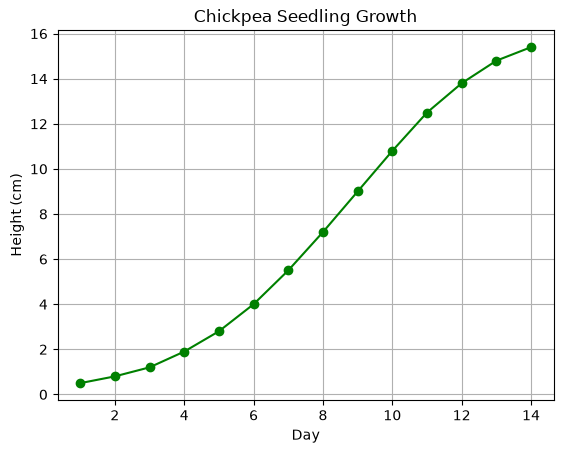

In [2]:
import matplotlib.pyplot as plt

days = list(range(1, 15))
heights = [0.5, 0.8, 1.2, 1.9, 2.8, 4.0, 5.5, 7.2, 9.0, 10.8, 12.5, 13.8, 14.8, 15.4]

plt.plot(days, heights, marker='o', color='green')
plt.xlabel("Day")
plt.ylabel("Height (cm)")
plt.title("Chickpea Seedling Growth")
plt.grid(True)
plt.show()

### Your First Plot

In [3]:
import matplotlib.pyplot as plt

### Your First Plot

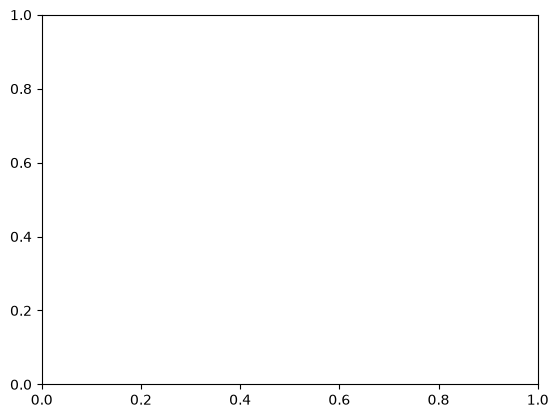

In [4]:
fig, ax = plt.subplots()

### Code 8.1: A basic line plot

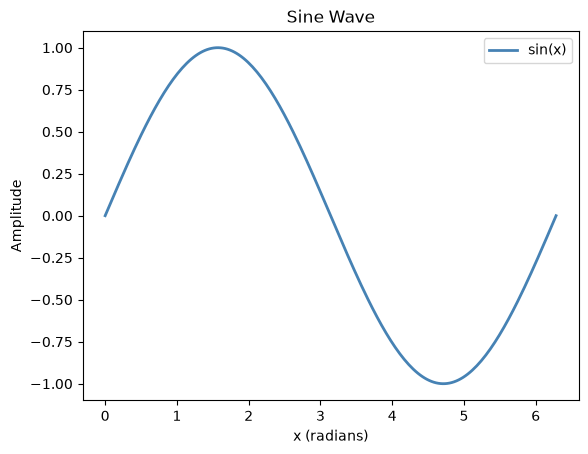

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2 * np.pi, 200)
y = np.sin(x)

fig, ax = plt.subplots()
ax.plot(x, y, color='steelblue', linewidth=2, label='sin(x)')
ax.set_xlabel('x (radians)')
ax.set_ylabel('Amplitude')
ax.set_title('Sine Wave')
ax.legend()
fig.savefig('sine_wave.pdf', bbox_inches='tight')
plt.show()

### Saving Figures Silently & Export Formats

In [6]:
import matplotlib
matplotlib.use('Agg')  # Headless non-interactive background renderer
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot([1, 2, 3], [4, 5, 6])
fig.savefig('silent_output.pdf', dpi=300, bbox_inches='tight')
plt.close(fig)  # Free memory resources silently

The listing above switched Matplotlib to file-only mode. The next cell switches the notebook back to showing plots.

In [7]:
%matplotlib inline

### Code 8.2: Scatter plot

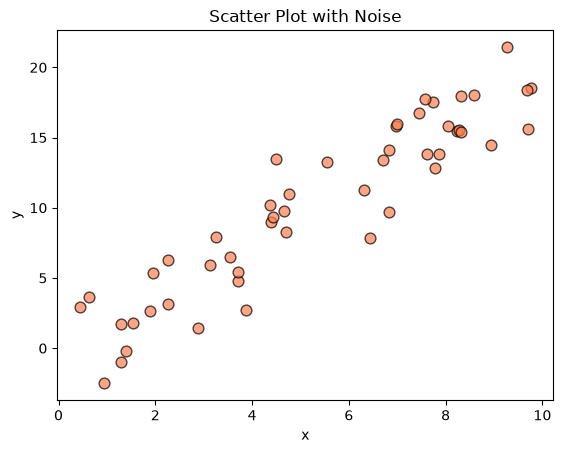

In [8]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
x = rng.uniform(0, 10, 50)
y = 2 * x + rng.normal(0, 3, 50)

fig, ax = plt.subplots()
ax.scatter(x, y, color='coral', alpha=0.7, edgecolors='k', s=60)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Scatter Plot with Noise')
fig.savefig('scatter_plot.pdf', bbox_inches='tight')
plt.show()

### Code 8.3: Vertical bar chart

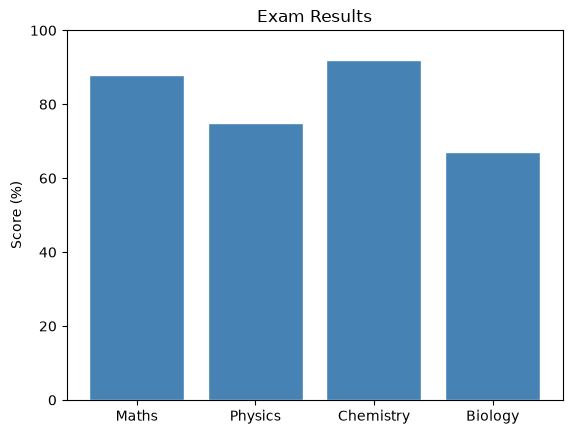

In [9]:
import matplotlib.pyplot as plt

subjects = ['Maths', 'Physics', 'Chemistry', 'Biology']
scores   = [88, 75, 92, 67]

fig, ax = plt.subplots()
ax.bar(subjects, scores, color='steelblue', edgecolor='white')
ax.set_ylim(0, 100)
ax.set_ylabel('Score (%)')
ax.set_title('Exam Results')
fig.savefig('bar_chart.pdf', bbox_inches='tight')
plt.show()

### Code 8.4: Histogram

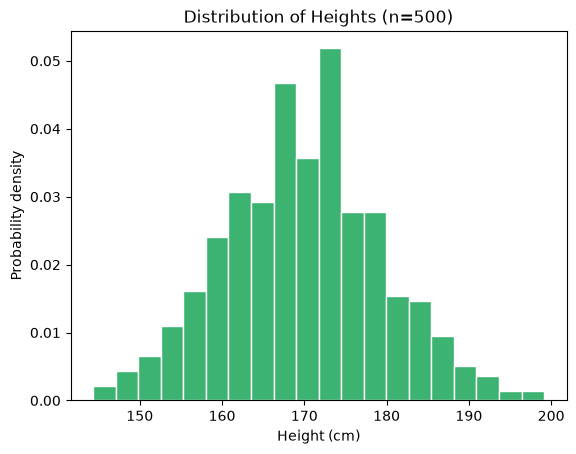

In [10]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
data = rng.normal(170, 10, 500)   # heights in cm

fig, ax = plt.subplots()
ax.hist(data, bins=20, color='mediumseagreen', edgecolor='white',
        density=True)
ax.set_xlabel('Height (cm)')
ax.set_ylabel('Probability density')
ax.set_title('Distribution of Heights (n=500)')
fig.savefig('histogram.pdf', bbox_inches='tight')
plt.show()

### The Grid Architecture of plt.subplots()

*Shown in the book as a fragment or a deliberate mistake; on its own it stops with NameError.* The code is shown here for reference:

```python
fig, axs = plt.subplots(nrows, ncols, figsize=(width, height))
```

### The Grid Architecture of plt.subplots()

*Shown in the book as a fragment or a deliberate mistake; on its own it stops with NameError.* The code is shown here for reference:

```python
for ax in axs.flat:
    ax.grid(True, linestyle=':')
```

### Code 8.5: 1 row, 2 columns of axes

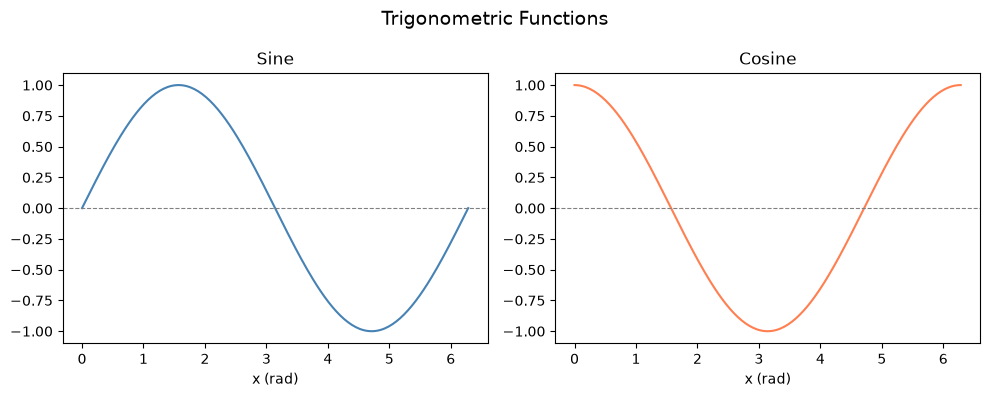

In [11]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2 * np.pi, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(x, np.sin(x), color='steelblue')
ax1.set_title('Sine')

ax2.plot(x, np.cos(x), color='coral')
ax2.set_title('Cosine')

for ax in (ax1, ax2):
    ax.set_xlabel('x (rad)')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

fig.suptitle('Trigonometric Functions', fontsize=14)
fig.tight_layout()
fig.savefig('subplots.pdf', bbox_inches='tight')
plt.show()

### Code 8.6: Comparing axis scales

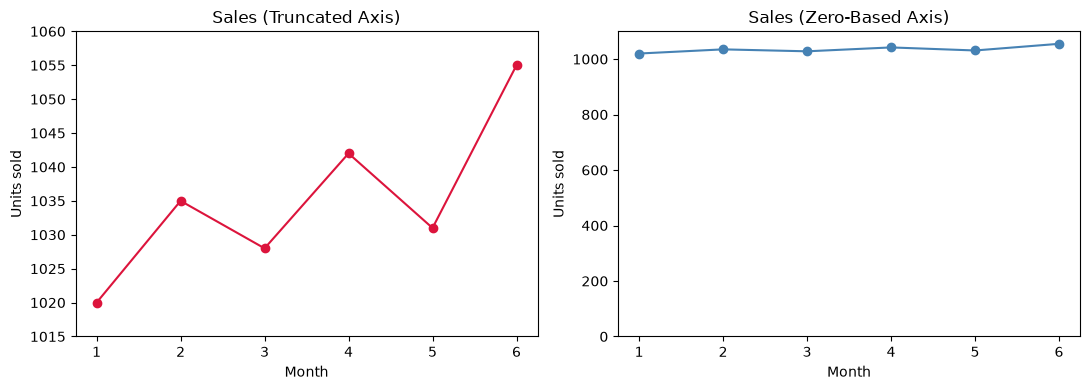

In [12]:
import numpy as np
import matplotlib.pyplot as plt

months = np.arange(1, 7)
sales  = np.array([1020, 1035, 1028, 1042, 1031, 1055])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Left: truncated y-axis
ax1.plot(months, sales, marker='o', color='crimson')
ax1.set_ylim(1015, 1060)
ax1.set_title('Sales (Truncated Axis)')

# Right: zero-based y-axis
ax2.plot(months, sales, marker='o', color='steelblue')
ax2.set_ylim(0, 1100)
ax2.set_title('Sales (Zero-Based Axis)')

for ax in (ax1, ax2):
    ax.set_xlabel('Month'); ax.set_ylabel('Units sold')

fig.tight_layout()
plt.show()

### Worked Example 8.1: Damped Harmonic Oscillator & Decay Envelopes

[DEBUG] Grid initialized: 500 points over interval [0, 8.0] s
Max Displacement at t=0: 5.0 cm
Residual Amplitude at t=8s: 0.0916 cm


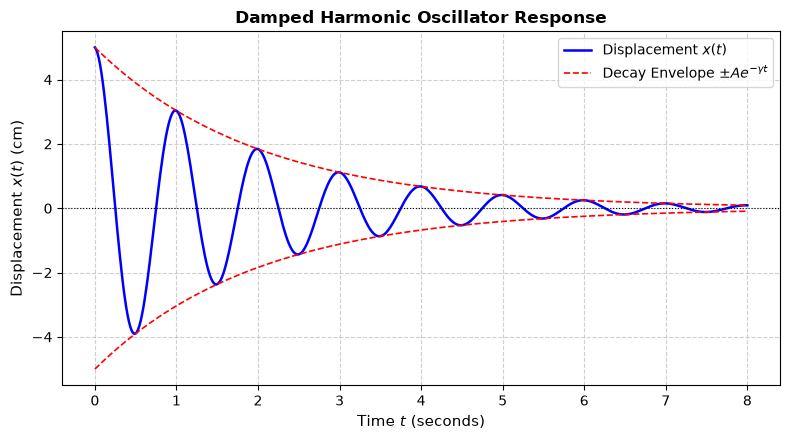

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
A = 5.0        # Initial amplitude (cm)
gamma = 0.5    # Damping rate (1/s)
omega = 2 * np.pi  # Angular frequency (rad/s)

# Time grid
t = np.linspace(0, 8, 500)
print(f"[DEBUG] Grid initialized: {len(t)} points over interval [0, {t[-1]}] s")

# Calculate displacement and envelope
x = A * np.exp(-gamma * t) * np.cos(omega * t)
env_upper = A * np.exp(-gamma * t)
env_lower = -env_upper

# Create plot
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=100)
ax.plot(t, x, 'b-', linewidth=1.8, label=r'Displacement $x(t)$')
ax.plot(t, env_upper, 'r--', linewidth=1.2, label=r'Decay Envelope $\pm A e^{-\gamma t}$')
ax.plot(t, env_lower, 'r--', linewidth=1.2)

# Styling and labels
ax.set_title('Damped Harmonic Oscillator Response', fontsize=12, fontweight='bold')
ax.set_xlabel('Time $t$ (seconds)', fontsize=11)
ax.set_ylabel('Displacement $x(t)$ (cm)', fontsize=11)
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right', frameon=True)
fig.tight_layout()

# Print confirmation
print(f"Max Displacement at t=0: {x[0]:.1f} cm")
print(f"Residual Amplitude at t=8s: {env_upper[-1]:.4f} cm")

# Output:
# [DEBUG] Grid initialized: 500 points over interval [0, 8.0] s
# Max Displacement at t=0: 5.0 cm
# Residual Amplitude at t=8s: 0.0916 cm

### Worked Example 8.2: Subplots - Signal Analysis in Time & Frequency Domains

[DEBUG] Signal sampling: N=500 points at fs=500 Hz
[DEBUG] Real FFT computed: 251 positive frequency bins
Dominant Frequencies Detected: [20.  5.] Hz


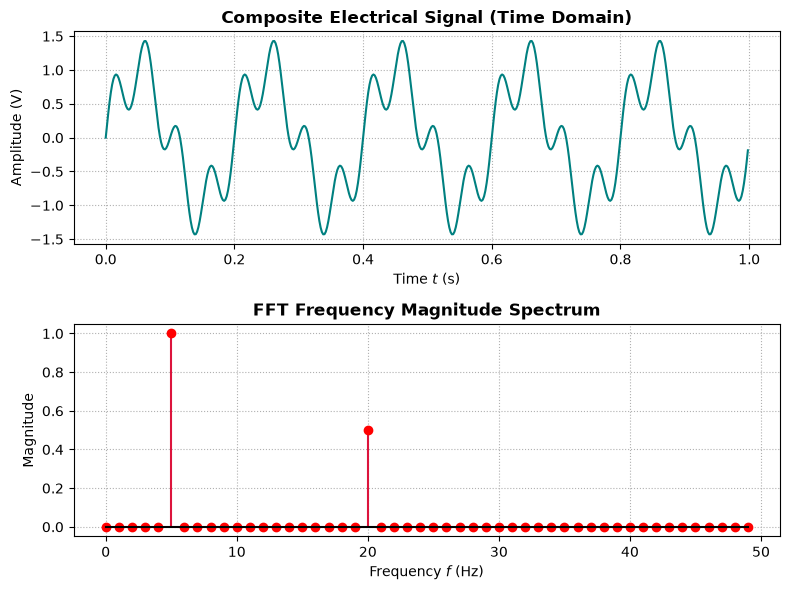

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Signal parameters
fs = 500       # Sampling frequency (Hz)
N = 500        # Total samples (1 second)
t = np.linspace(0, 1.0, N, endpoint=False)
print(f"[DEBUG] Signal sampling: N={N} points at fs={fs} Hz")

# Composite signal
y = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 20 * t)

# Compute FFT magnitude
fft_vals = np.fft.rfft(y)
freqs = np.fft.rfftfreq(N, 1/fs)
magnitude = 2.0 / N * np.abs(fft_vals)
print(f"[DEBUG] Real FFT computed: {len(freqs)} positive frequency bins")

# Create stacked subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=False)

# Top Panel: Time Domain
ax1.plot(t, y, color='teal', linewidth=1.5)
ax1.set_title('Composite Electrical Signal (Time Domain)', fontweight='bold')
ax1.set_xlabel('Time $t$ (s)')
ax1.set_ylabel('Amplitude (V)')
ax1.grid(True, linestyle=':')

# Bottom Panel: Frequency Domain
ax2.stem(freqs[:50], magnitude[:50], linefmt='crimson', markerfmt='ro', basefmt='k-')
ax2.set_title('FFT Frequency Magnitude Spectrum', fontweight='bold')
ax2.set_xlabel('Frequency $f$ (Hz)')
ax2.set_ylabel('Magnitude')
ax2.grid(True, linestyle=':')

plt.tight_layout()

print(f"Dominant Frequencies Detected: {freqs[np.argsort(magnitude)[-2:]]} Hz")

# Output:
# [DEBUG] Signal sampling: N=500 points at fs=500 Hz
# [DEBUG] Real FFT computed: 251 positive frequency bins
# Dominant Frequencies Detected: [20.  5.] Hz

### Worked Example 8.3: 2D Electrostatic Potential Field Contour Plot

[DEBUG] Spatial grid X, Y created with shape (201, 201)
[DEBUG] Potential V evaluated: min=0.23 V, max=1.41 V


Peak Potential at Origin: 1.4142 V


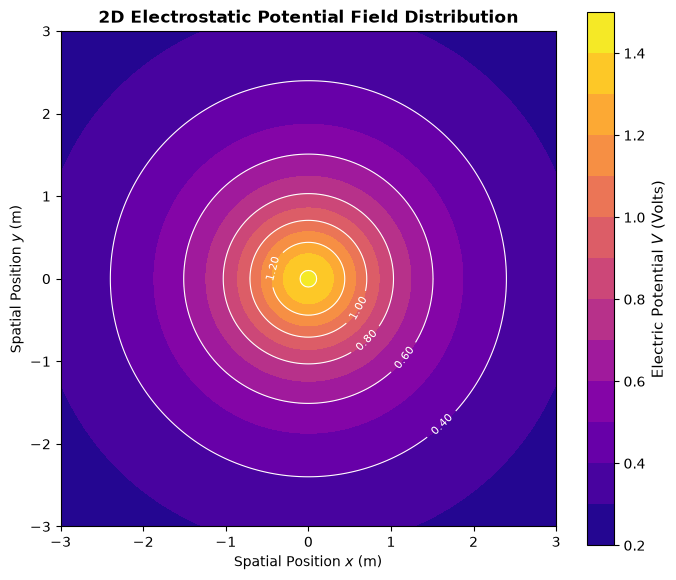

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 2D spatial grid
x = np.linspace(-3, 3, 201)   # odd count, so x = 0 is a grid point
y = np.linspace(-3, 3, 201)
X, Y = np.meshgrid(x, y)
print(f"[DEBUG] Spatial grid X, Y created with shape {X.shape}")

# Evaluate potential field V(x, y)
V = 1.0 / np.sqrt(X**2 + Y**2 + 0.5)
print(f"[DEBUG] Potential V evaluated: min={V.min():.2f} V, max={V.max():.2f} V")

# Plot filled contours using object-oriented ax interface
fig, ax = plt.subplots(figsize=(7, 6), dpi=100)
contour_filled = ax.contourf(X, Y, V, levels=12, cmap='plasma')
cbar = fig.colorbar(contour_filled, ax=ax)
cbar.set_label('Electric Potential $V$ (Volts)', fontsize=11)

# Overlay contour lines with numerical labels
lines = ax.contour(X, Y, V, levels=6, colors='white', linewidths=0.8)
ax.clabel(lines, inline=True, fontsize=8, fmt='%.2f')

ax.set_title('2D Electrostatic Potential Field Distribution', fontweight='bold')
ax.set_xlabel('Spatial Position $x$ (m)')
ax.set_ylabel('Spatial Position $y$ (m)')
ax.set_aspect('equal')
fig.tight_layout()

print(f"Peak Potential at Origin: {V[100, 100]:.4f} V")

# Output:
# [DEBUG] Spatial grid X, Y created with shape (201, 201)
# [DEBUG] Potential V evaluated: min=0.23 V, max=1.41 V
# Peak Potential at Origin: 1.4142 V

### Worked Example 8.4: Statistical Data Visualization with Error Bars

[DEBUG] Loaded 5 experimental viscosity data points
Relative Error at T=20C: 5.0%


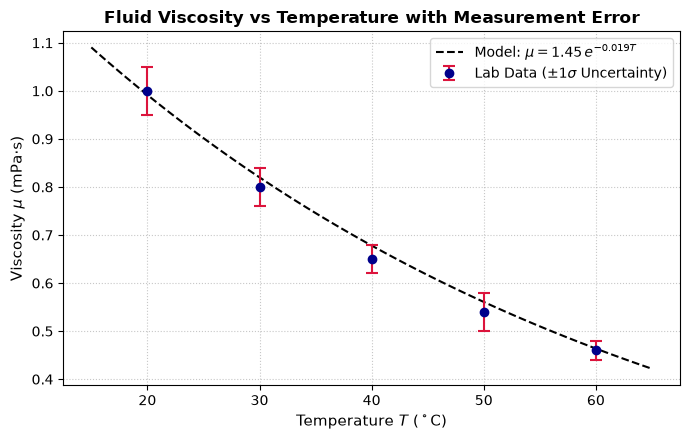

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Experimental data
T_data = np.array([20, 30, 40, 50, 60])
mu_data = np.array([1.00, 0.80, 0.65, 0.54, 0.46])
sigma_mu = np.array([0.05, 0.04, 0.03, 0.04, 0.02])
print(f"[DEBUG] Loaded {len(T_data)} experimental viscosity data points")

# Theoretical model curve: mu(T) = 1.45 * exp(-0.019 * T)
T_fine = np.linspace(15, 65, 100)
mu_theory = 1.45 * np.exp(-0.019 * T_fine)

# Object-oriented figure and axes initialization
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=100)

# Plot theoretical model curve
ax.plot(T_fine, mu_theory, 'k--', label=r'Model: $\mu = 1.45\,e^{-0.019 T}$')

# Overlay experimental measurements with error bars
ax.errorbar(T_data, mu_data, yerr=sigma_mu, fmt='o', color='darkblue',
            ecolor='crimson', elinewidth=1.5, capsize=4, capthick=1.5,
            label=r'Lab Data ($\pm 1\sigma$ Uncertainty)')

ax.set_title('Fluid Viscosity vs Temperature with Measurement Error', fontweight='bold')
ax.set_xlabel(r'Temperature $T$ ($^\circ$C)', fontsize=11)
ax.set_ylabel(r'Viscosity $\mu$ (mPa$\cdot$s)', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='upper right')
fig.tight_layout()

print("Relative Error at T=20C:", f"{sigma_mu[0]/mu_data[0]*100:.1f}%")

# Output:
# [DEBUG] Loaded 5 experimental viscosity data points
# Relative Error at T=20C: 5.0%

### Worked Example 8.5: Data Visualization Ethics - The Space Shuttle Challenger O-Ring Dataset

[DEBUG] 23 flights, 7 with O-ring damage


Below 65 F: 4 of 4 flights damaged
65 F and above: 3 of 19 flights damaged


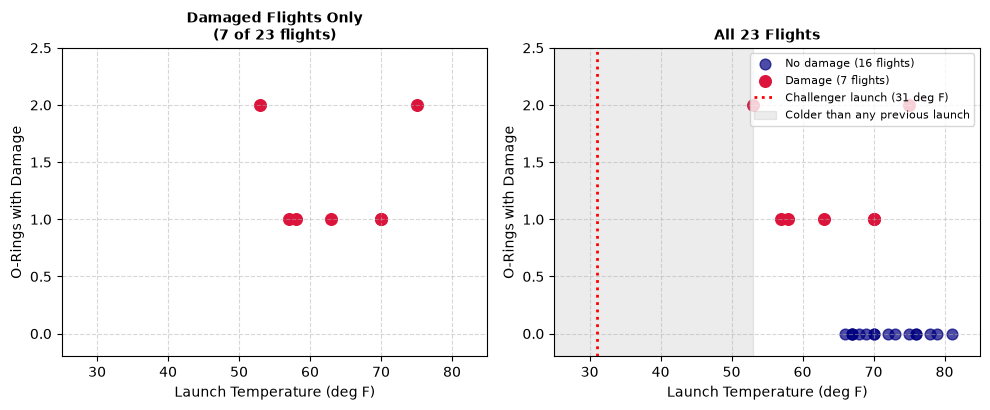

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 23 pre-Challenger flights: launch temperature (deg F) and number of
# field-joint O-rings showing thermal distress (Dalal et al., 1989)
temps = np.array([66, 70, 69, 68, 67, 72, 73, 70, 57, 63, 70, 78,
                  67, 53, 67, 75, 70, 81, 76, 79, 75, 76, 58])
incidents = np.array([0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
                      0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 1])

damaged = incidents > 0
print(f"[DEBUG] {len(temps)} flights, {np.sum(damaged)} with O-ring damage")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2))

# Panel 1: only the flights that had damage
ax1.scatter(temps[damaged], incidents[damaged], color='crimson', s=70)
ax1.set_xlim(25, 85); ax1.set_ylim(-0.2, 2.5)
ax1.set_title('Damaged Flights Only\n(7 of 23 flights)', fontsize=10, fontweight='bold')
ax1.set_xlabel('Launch Temperature (deg F)')
ax1.set_ylabel('O-Rings with Damage')
ax1.grid(True, linestyle='--', alpha=0.5)

# Panel 2: all 23 flights, plus the Challenger launch temperature
ax2.scatter(temps[~damaged], incidents[~damaged], color='navy', s=60,
            alpha=0.7, label='No damage (16 flights)')
ax2.scatter(temps[damaged], incidents[damaged], color='crimson', s=70,
            label='Damage (7 flights)')
ax2.axvline(31, color='red', linestyle=':', linewidth=2,
            label='Challenger launch (31 deg F)')
ax2.axvspan(25, temps.min(), color='gray', alpha=0.15,
            label='Colder than any previous launch')
ax2.set_xlim(25, 85); ax2.set_ylim(-0.2, 2.5)
ax2.set_title('All 23 Flights', fontsize=10, fontweight='bold')
ax2.set_xlabel('Launch Temperature (deg F)')
ax2.set_ylabel('O-Rings with Damage')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right', fontsize=8)

fig.tight_layout()
fig.savefig('challenger_oring_analysis.pdf')

cold = temps < 65
print(f"Below 65 F: {np.sum(damaged & cold)} of {np.sum(cold)} flights damaged")
print(f"65 F and above: {np.sum(damaged & ~cold)} of {np.sum(~cold)} flights damaged")

# Output:
# [DEBUG] 23 flights, 7 with O-ring damage
# Below 65 F: 4 of 4 flights damaged
# 65 F and above: 3 of 19 flights damaged